In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/Titanic-Dataset.csv")

INSPECT THE DATASET

In [3]:
df.shape #checks the dimensions of the dataframe

(891, 12)

In [4]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.head() #displays first 5 rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.describe() #gives the summary stats of numerical columns

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


CHECK AND HANDLE MISSING VALUES

In [8]:
df.isnull().sum() #gives the missing values of each column

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
missing_percentage = (df.isnull().sum() / len(df)) *100
missing_percentage.sort_values(ascending = True)

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000
Embarked,0.224467


In [11]:
# Find the median age
age_median = df["Age"].median()

print("Median age:", age_median)

Median age: 28.0


In [12]:
# Replace missing Age values with the median
df["Age"] = df["Age"].fillna(age_median)

In [13]:
embarked_mode = df["Embarked"].mode()[0]
print("most common embarked",embarked_mode)

most common embarked S


In [14]:
df["Embarked"]=df["Embarked"].fillna(embarked_mode)

In [15]:
# Create a feature indicating whether the passenger has cabin information
df["CabinKnown"] = df["Cabin"].notnull().astype(int)

In [16]:
# Replace missing Cabin values with "Unknown"
df["Cabin"] = df["Cabin"].fillna("Unknown")

In [17]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinKnown
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,0


In [18]:

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [19]:
# Count the duplicated rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


VISUALIZING OUTLIERS

In [20]:
# Display summary statistics for important numerical columns
df[["Age", "Fare", "SibSp", "Parch"]].describe()

,Age,Fare,SibSp,Parch
count,891.000000,891.000000,891.000000,891.000000
mean,29.361582,32.204208,0.523008,0.381594
std,13.019697,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,35.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


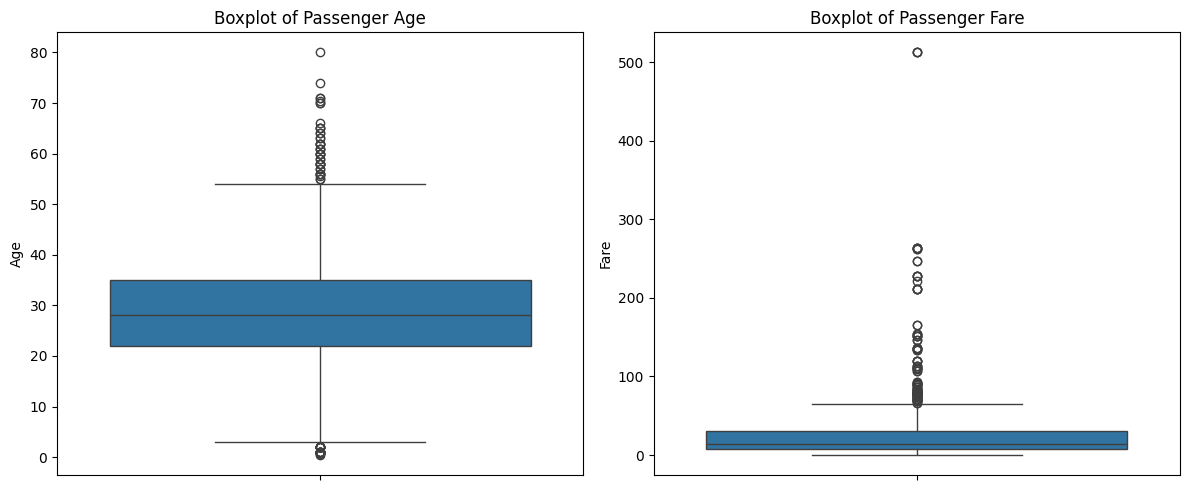

In [21]:
#boxplots to visually identify outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df["Age"], ax=axes[0])
axes[0].set_title("Boxplot of Passenger Age")

sns.boxplot(y=df["Fare"], ax=axes[1])
axes[1].set_title("Boxplot of Passenger Fare")

plt.tight_layout()
plt.show()

In [22]:
# Find ages that are unrealistic
invalid_ages = df[(df["Age"] < 0) | (df["Age"] > 100)]

print("Number of invalid age values:", len(invalid_ages))
invalid_ages

Number of invalid age values: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinKnown


In [23]:
# Find negative fare values
invalid_fares = df[df["Fare"] < 0]

print("Number of negative fare values:", len(invalid_fares))
invalid_fares

Number of negative fare values: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinKnown


In [24]:
# Calculate the first and third quartiles for Fare
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

# Calculate the interquartile range
IQR = Q3 - Q1

# Define the lower and upper outlier limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Lower limit: -26.724
Upper limit: 65.6344


In [25]:
# Identify possible Fare outliers
fare_outliers = df[
    (df["Fare"] < lower_limit) |
    (df["Fare"] > upper_limit)
]

print("Number of possible Fare outliers:", len(fare_outliers))

Number of possible Fare outliers: 116


In [26]:
# Reduce the skewness caused by very high Fare values
df["FareLog"] = np.log1p(df["Fare"])

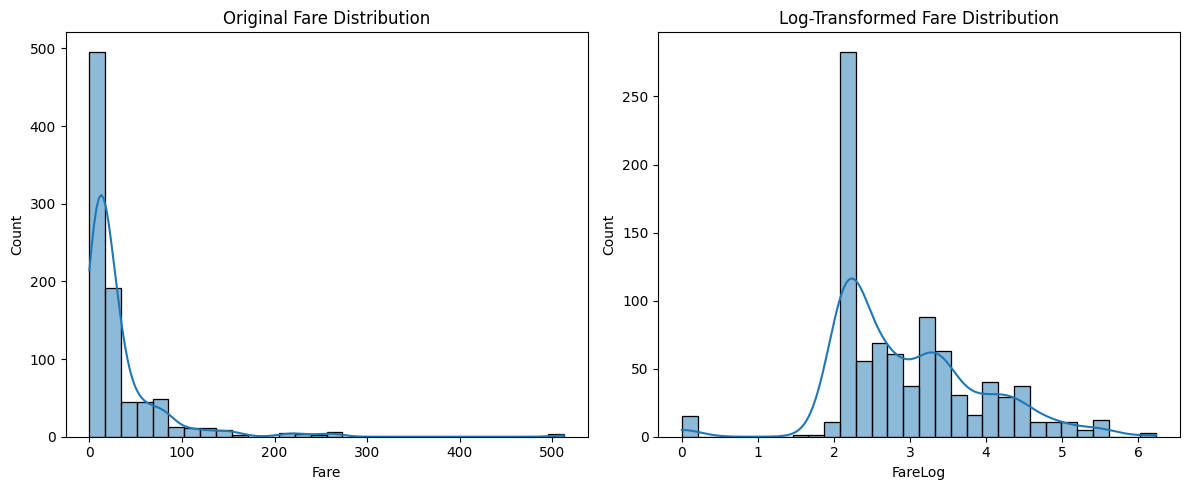

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["Fare"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Original Fare Distribution")

sns.histplot(df["FareLog"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Log-Transformed Fare Distribution")

plt.tight_layout()
plt.show()

In [28]:
# Confirm that no clearly invalid values remain
print("Negative ages:", (df["Age"] < 0).sum())
print("Ages above 100:", (df["Age"] > 100).sum())
print("Negative fares:", (df["Fare"] < 0).sum())

Negative ages: 0
Ages above 100: 0
Negative fares: 0


VISUALIZATIONS

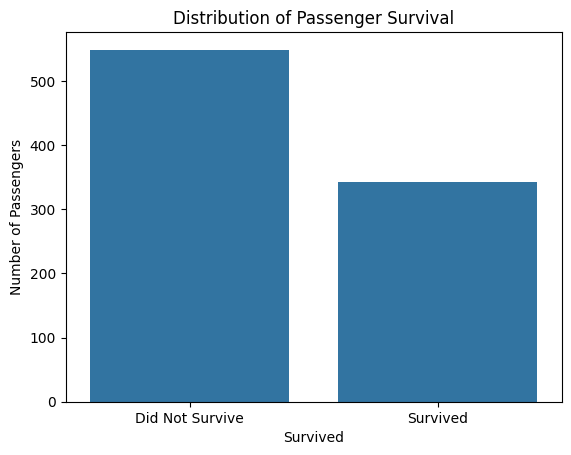

In [29]:
# Create a count plot showing survived and non-survived passengers
sns.countplot(data=df, x="Survived")

plt.title("Distribution of Passenger Survival") #title
plt.xticks([0, 1], ["Did Not Survive", "Survived"]) #a-xis categories
plt.ylabel("Number of Passengers") #y-axis categories
plt.show()

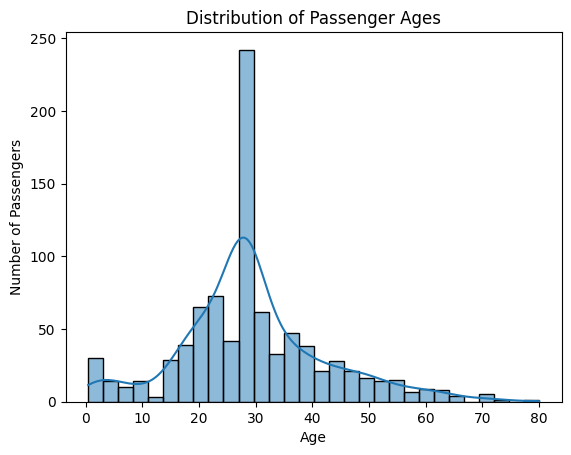

In [30]:
# Create a histogram of passenger ages
sns.histplot(data=df, x="Age", bins=30, kde=True)


plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

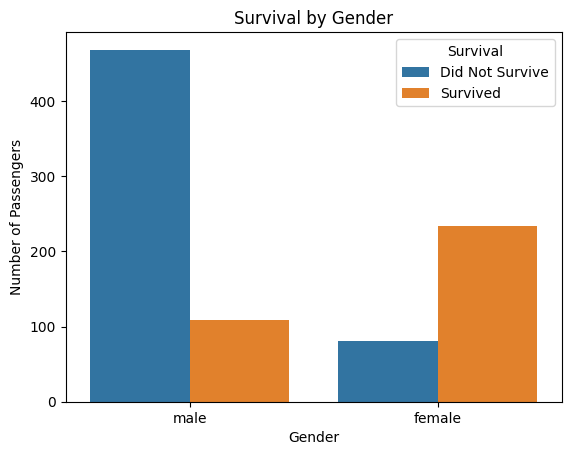

In [31]:
# Create a count plot comparing survival by gender
sns.countplot(data=df, x="Sex", hue="Survived")


plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survival", labels=["Did Not Survive", "Survived"])
plt.show()

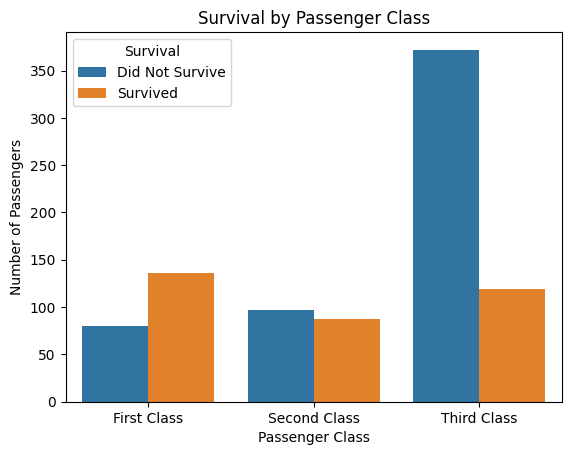

In [32]:
# Create a count plot comparing survival across passenger classes
sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.xticks([0, 1, 2], ["First Class", "Second Class", "Third Class"])
plt.legend(title="Survival", labels=["Did Not Survive", "Survived"])
plt.show()

In [33]:
# Select numerical columns for correlation analysis
correlation_columns = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "CabinKnown",
    "FareLog"
]

correlation_matrix = df[correlation_columns].corr() #correlation matrix
correlation_matrix

,Survived,Pclass,Age,SibSp,Parch,Fare,CabinKnown,FareLog
Survived,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307,0.316912,0.329862
Pclass,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500,-0.725541,-0.661022
Age,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688,0.240314,0.110964
SibSp,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651,-0.040460,0.318528
Parch,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225,0.036987,0.332186
Fare,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000,0.482075,0.787543
CabinKnown,0.316912,-0.725541,0.240314,-0.040460,0.036987,0.482075,1.000000,0.557192
FareLog,0.329862,-0.661022,0.110964,0.318528,0.332186,0.787543,0.557192,1.000000


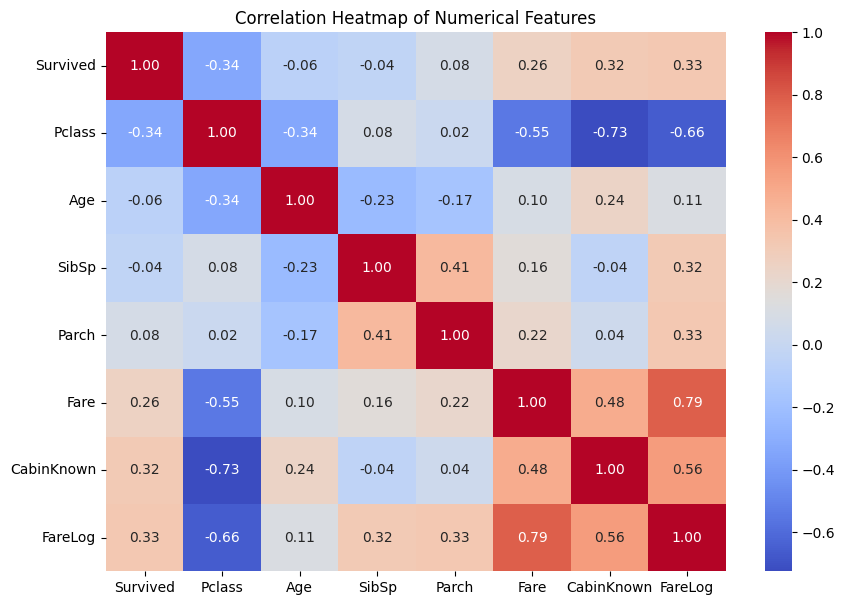

In [34]:
# Set the chart size
plt.figure(figsize=(10, 7))

# Create the correlation heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

FEATURE ENGINEERING

In [35]:
#FEATURE-1
# Create total family size
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [36]:
df[["SibSp", "Parch", "FamilySize"]].head(10)

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


In [37]:
#FEATURE-2
# Create a feature indicating whether the passenger traveled alone
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [38]:
df[["FamilySize", "IsAlone"]].head(10)

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
5,1,1
6,1,1
7,5,0
8,3,0
9,2,0


In [39]:
df["Name"].head(10)

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"
5,"Moran, Mr. James"
6,"McCarthy, Mr. Timothy J"
7,"Palsson, Master. Gosta Leonard"
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)"
9,"Nasser, Mrs. Nicholas (Adele Achem)"


In [40]:
# Extract the text appearing between the comma and period
df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.")

In [41]:
df[["Name", "Title"]].head(10)

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr
5,"Moran, Mr. James",Mr
6,"McCarthy, Mr. Timothy J",Mr
7,"Palsson, Master. Gosta Leonard",Master
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Mrs
9,"Nasser, Mrs. Nicholas (Adele Achem)",Mrs


In [42]:
df["Title"].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [43]:
# List the most common passenger titles
common_titles = ["Mr", "Miss", "Mrs", "Master"]

# Replace uncommon titles with the label "Rare"
df["Title"] = df["Title"].where(
    df["Title"].isin(common_titles),
    "Rare"
)

In [44]:
df["Title"].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Rare,27


In [45]:
# Display the newly created features
df[
    [
        "CabinKnown",
        "FareLog",
        "FamilySize",
        "IsAlone",
        "Title"
    ]
].head(10)

,CabinKnown,FareLog,FamilySize,IsAlone,Title
0,0,2.110213,2,0,Mr
1,1,4.280593,2,0,Mrs
2,0,2.188856,1,1,Miss
3,1,3.990834,2,0,Mrs
4,0,2.202765,1,1,Mr
5,0,2.246893,1,1,Mr
6,1,3.967694,1,1,Mr
7,0,3.094446,5,0,Master
8,0,2.495954,3,0,Mrs
9,0,3.436268,2,0,Mrs


In [46]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'CabinKnown', 'FareLog',
       'FamilySize', 'IsAlone', 'Title'],
      dtype='object')

FINAL INSIGHTS


1. The overall survival rate was low because more passengers did not survive than those who survived.

2. Female passengers had a much better survival rate compared to male passengers. This shows that gender played an important role in survival.

3. Passenger class also had a clear impact. First-class passengers had a higher chance of survival, while third-class passengers had the lowest survival rate.

4. Passengers who traveled with family had different survival patterns compared to those who traveled alone. Because of this, features like `FamilySize` and `IsAlone` could be useful for future prediction models.

5. Passengers with higher ticket fares or known cabin information generally had better survival outcomes. This suggests that fare and cabin details were also related to survival.
